# Linear Regression — Complete Guide (From Scratch to Scikit-Learn)

This notebook brings together the full Linear Regression journey in one place:

1. **Simple Linear Regression** — one input feature ($y = wx + b$). We build the
   prediction function, manually tune parameters, define the cost function, and
   implement **Gradient Descent** from scratch to learn the best fit automatically.
2. **Multiple Linear Regression** — many input features
   ($y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$), implemented in a vectorized way
   with NumPy.
3. **Scikit-Learn** — the industry-standard way using `LinearRegression` and
   `SGDRegressor`, compared against our from-scratch results.

The goal is intuition first (what the math is doing), then the practical tools.

## 0. Imports & Setup
We rely on three libraries throughout:
- **NumPy** for numerical arrays and fast math.
- **Matplotlib** for plotting.
- **Seaborn** for prettier statistical plots (built on top of Matplotlib).

In [1]:
import numpy as np                 # Handling numerical arrays
import matplotlib.pyplot as plt    # Creating plots
import seaborn as sns              # Prettier statistical plots (built on matplotlib)

# Set a clean default style for all our plots
sns.set_theme()

---
# Part 1 — Simple Linear Regression

A **simple** linear regression model maps a single input feature `X` to a target
`y` using a straight line:

$$ f(x) = wx + b $$

- $w$ (**weight**) controls the **slope** of the line.
- $b$ (**bias**) controls the **y-intercept** (shifts the line up/down).

Our job is to find the $w$ and $b$ that make the line fit the data as closely as
possible.

## 1.1 Setup Data
We define our input feature `X` (Years of Experience) and our target label `y`
(Salary, in thousands).

In [2]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1, 3, 4, 6, 7])    # Years of experience

# y represents our 'Target' (the value we want the model to learn to predict)
y = np.array([15, 35, 45, 65, 75])  # Salary in thousands

## 1.2 Visualize the Raw Data
Before modeling, we look at the data points to check whether a (linear)
relationship exists between experience and salary.

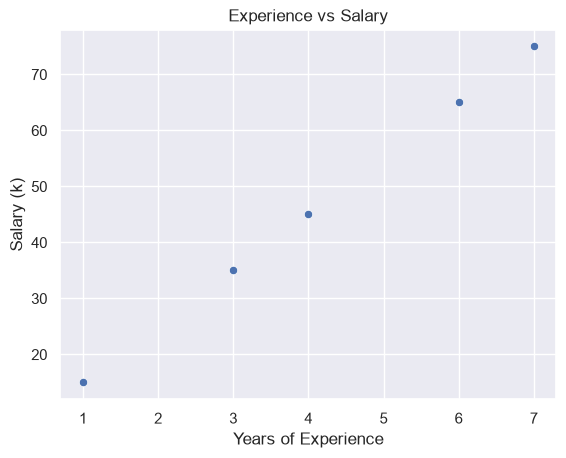

In [3]:
# Scatter plot to see the relationship between X and y
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.title("Experience vs Salary")
plt.show()

## 1.3 The Prediction Function
The function below implements the linear formula $f(x) = wx + b$ for every data
point.

In [4]:
def make_prediction(X, y, w, b):
  """
  Calculates predictions using the linear regression formula: y = wx + b
  w: weight (slope)
  b: bias (intercept)
  """
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Empty array to store our results

  for i in range(m):
    # Prediction for each specific data point
    pred_list[i] = w * X[i] + b

  return pred_list

## 1.4 Experimenting with Parameters
Now we test different values of `w` and `b` to see how well the resulting line
fits the data. This builds intuition for what $w$ and $b$ actually do, before we
automate the search.

Predictions (w=0, b=0): [0. 0. 0. 0. 0.]


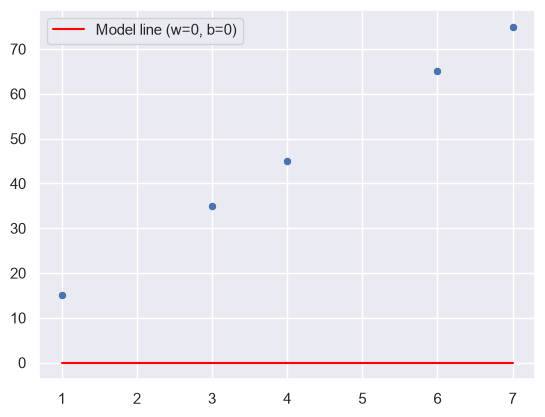

In [5]:
# Start with w=0 and b=0 (a flat line sitting at zero)
predictions = make_prediction(X, y, 0, 0)
print(f"Predictions (w=0, b=0): {predictions}")

# Visualize how this 'zero' model fits the data
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=0, b=0)')
plt.legend()
plt.show()

### Case 1: Minimal slope
Here $w=1, b=0$. The line is far below the data points — the slope is too small.

Predictions (w=1, b=0): [1. 3. 4. 6. 7.]


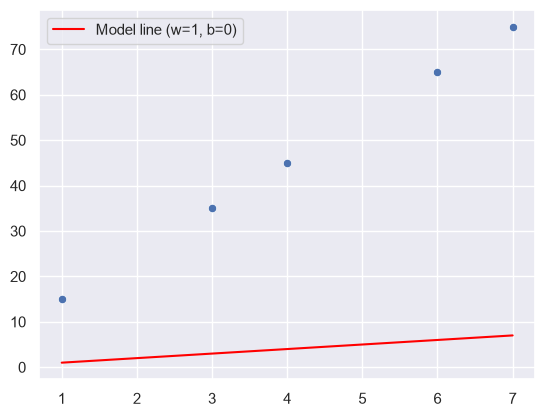

In [6]:
predictions = make_prediction(X, y, w=1, b=0)
print(f"Predictions (w=1, b=0): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=1, b=0)')
plt.legend()
plt.show()

### Case 2: Increasing the slope
Using $w=5, b=3$ brings the line closer, but it's still not quite there.

Predictions (w=5, b=3): [ 8. 18. 23. 33. 38.]


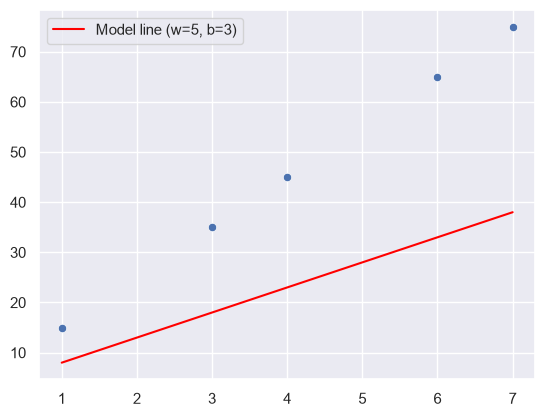

In [7]:
predictions = make_prediction(X, y, w=5, b=3)
print(f"Predictions (w=5, b=3): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=5, b=3)')
plt.legend()
plt.show()

### Case 3: Finding a good fit by hand
With $w=10, b=5$, we see a much better alignment with the data points — in fact,
for this small dataset it's a perfect fit.

Predictions (w=10, b=5): [15. 35. 45. 65. 75.]


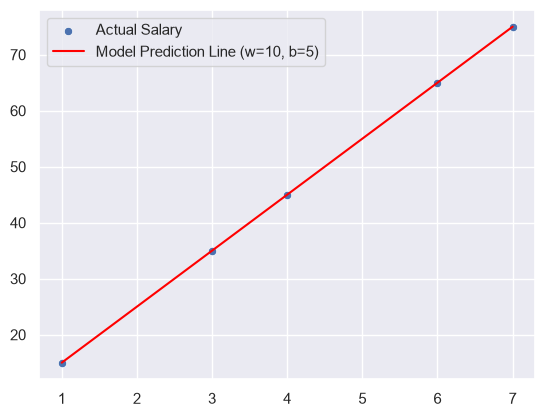

In [8]:
predictions = make_prediction(X, y, w=10, b=5)
print(f"Predictions (w=10, b=5): {predictions}")

# Plot the actual data points
sns.scatterplot(x=X, y=y, label='Actual Salary')
# Draw the model's prediction line
plt.plot(X, predictions, color='red', label='Model Prediction Line (w=10, b=5)')
plt.legend()
plt.show()

## 1.5 Cost Function (Mean Squared Error)
Eyeballing the line works for a tiny dataset, but we need a **number** that tells
us how good a fit is. That is the **cost** — here we use Mean Squared Error (MSE):

$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f(x^{(i)}) - y^{(i)} \right)^2 $$

A **lower cost means a better fit**. We divide by $2m$ instead of $m$ purely for
mathematical convenience — the $2$ cancels nicely when we take derivatives during
gradient descent.

In [9]:
def compute_cost(X, y, w, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]   # Difference between prediction and actual value
    error_squared = error ** 2
    cost = cost + error_squared

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

## 1.6 Visualizing the Cost
Let's attach the cost to a few candidate lines, then plot how the cost changes as
we sweep the weight $w$ (keeping $b$ fixed). The result is a convex, **U-shaped**
curve — and the lowest point of that "U" is exactly the $w$ we want.

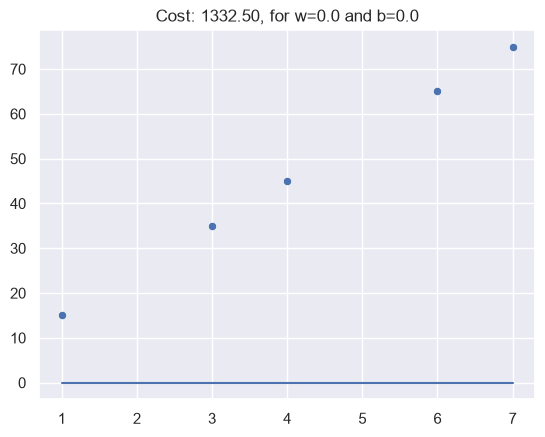

In [10]:
w = 0.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
# The title shows the cost, helping us see how 'wrong' this line is
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[1. 3. 4. 6. 7.]


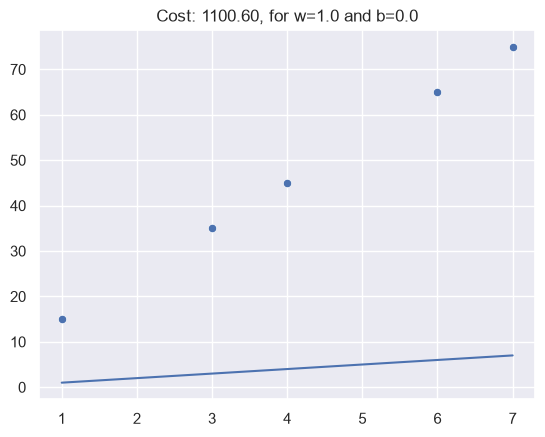

In [11]:
w = 1.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[ 3.  7.  9. 13. 15.]


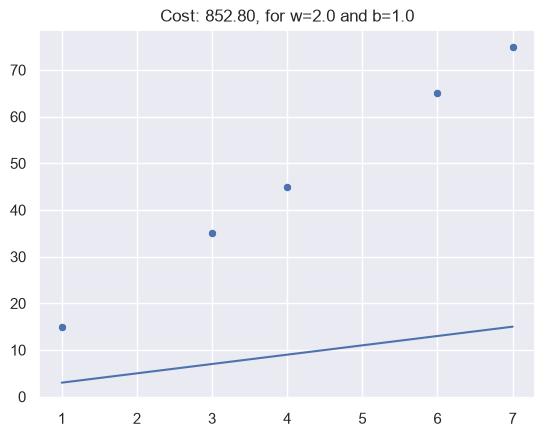

In [12]:
w = 2.0
b = 1.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[15. 35. 45. 65. 75.]


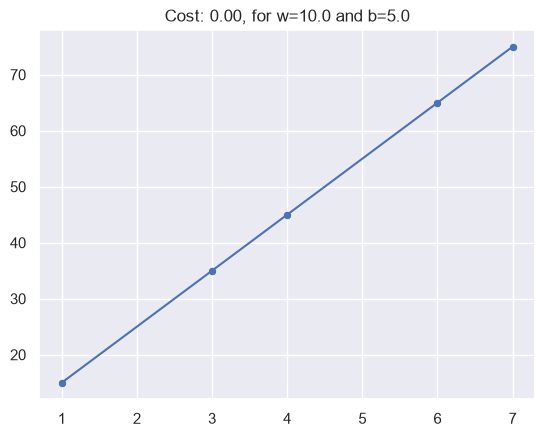

In [13]:
w = 10.0
b = 5.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

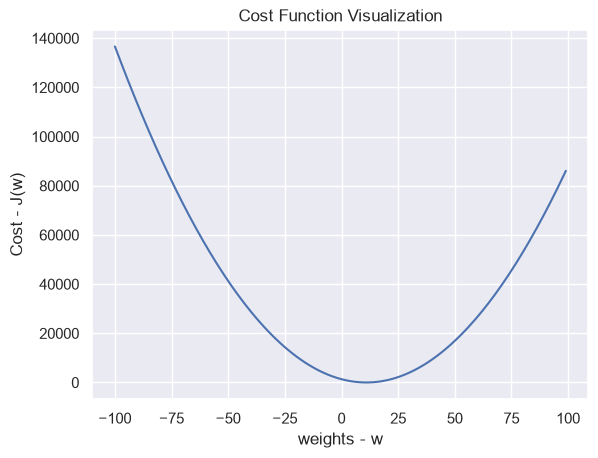

In [14]:
w_range = []
cost_history = []

# Loop through different weight values to see how each affects the cost
for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w_range.append(i)
    cost_history.append(cost_i)

# Plotting the Cost Function: the goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

## 1.7 Gradient Descent
Instead of guessing parameter values, we use the **gradient** (the slope of the
cost curve) to know which direction to nudge $w$ and $b$ so the cost goes *down*.

The partial derivatives of the cost are:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)})\,x^{(i)}
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)}) $$

We then repeatedly update the parameters by a small step (the **learning rate**
$\alpha$) against the gradient:

$$ w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial J}{\partial b} $$

In [15]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b."""
  m = X.shape[0]
  dj_dw = 0.0   # Change needed for the weight
  dj_db = 0.0   # Change needed for the bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [16]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Run Gradient Descent
We initialize $w$ and $b$ at 0 and let the algorithm find the best values.

In [17]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01
)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Notice how the gradients (`dj_dw`, `dj_db`) and the cost shrink toward zero over
the iterations. Once the algorithm **converges** to the minimum point of the cost
function, the updates become tiny and it effectively stops changing $w$ and $b$.

## 1.8 Final Results & Prediction
With the optimized parameters we can draw the best-fit line and predict the salary
for a brand-new input (e.g. someone with 2 years of experience).

Optimized w: 10.0000, b: 5.0000


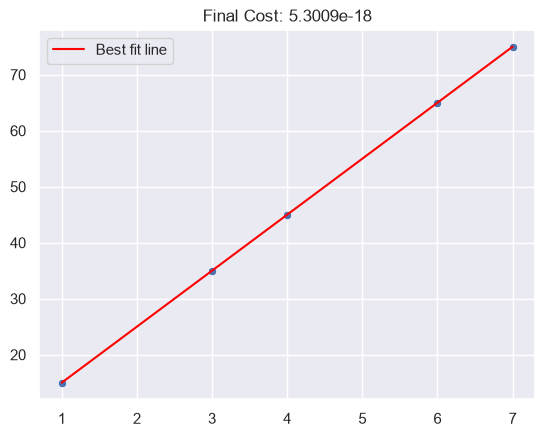

In [18]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [19]:
# Example: predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


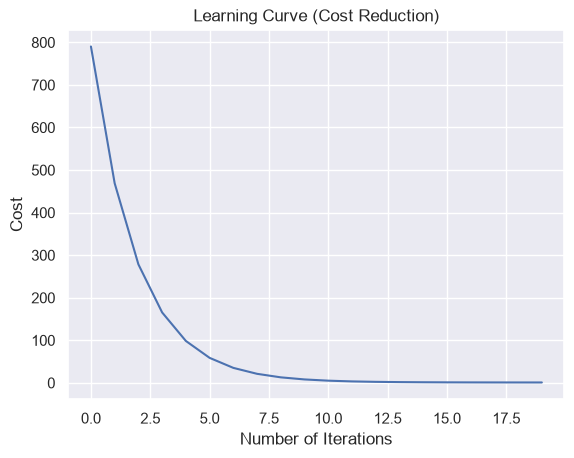

In [20]:
# Plot the cost over the first 20 iterations to see it dropping fast (learning curve)
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

---
# Part 2 — Multiple Linear Regression

Real problems rarely depend on a single feature. **Multiple** linear regression
extends the same idea to many input features:

$$ f(\mathbf{x}) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = \mathbf{w}\cdot\mathbf{x} + b $$

The structure is identical — prediction, cost, gradient descent — but now $\mathbf{w}$
is a **vector** of weights (one per feature) and we use the dot product.

## 2.1 Data Preparation
Each row of `X` is one person; each column is a feature:

| Column | Feature |
|--------|---------|
| 0 | Years of Experience |
| 1 | Problem-Solving (PS) Skill |
| 2 | Pause Time During Interview |
| 3 | GPA |

The target `y` is Salary. (This synthetic data was generated with true weights
`w = [5, 10, -2, 0.5]` and `b = 2.0`, so we have a known answer to check against.)

In [21]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])

# True parameters used to generate y:  w = [5, 10, -2, 0.5] , b = 2.0
y = np.array([45.9, 76.55, 92.35, 107.9, 128.])

Let's visualize each feature against the target to sanity-check the relationships.

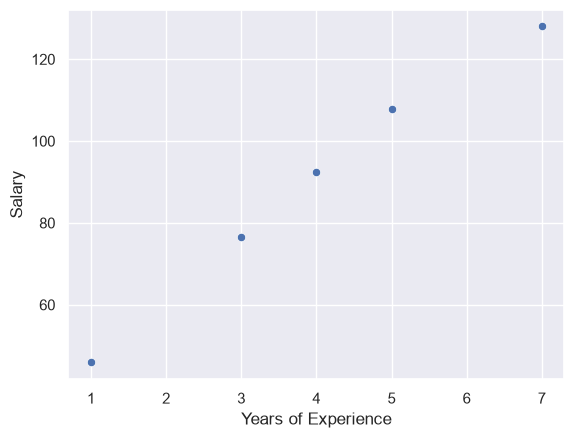

In [22]:
# Feature 0: Years of Experience
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

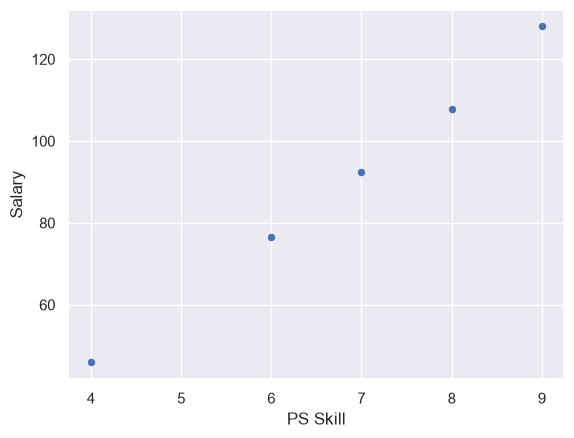

In [23]:
# Feature 1: Problem-Solving Skill
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

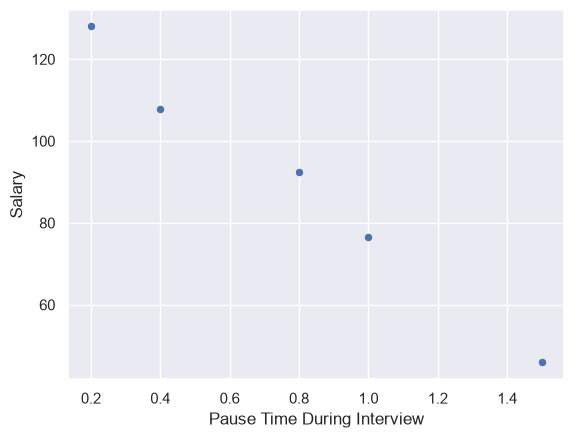

In [24]:
# Feature 2: Pause Time During Interview
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

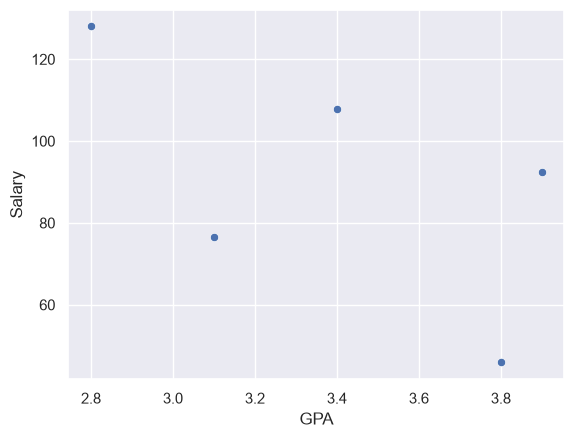

In [25]:
# Feature 3: GPA
sns.scatterplot(x=X[:, 3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

## 2.2 Manual Implementation (Vectorized)
We rebuild the same three components, now generalized to $n$ features:

1. **Prediction** — $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$ (dot product).
2. **Cost** — Mean Squared Error, computed with vectorized NumPy operations.
3. **Gradient Descent** — adjusts the weight *vector* $\mathbf{w}$ and bias $b$.

### Prediction function
Note the signature changes to `(X, W, b)` and uses `np.dot(W, X[i])` so it works
for any number of features.

In [26]:
def make_prediction(X, W, b):
  """Calculates the model output: f(x) = W·x + b (for multiple features)."""
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Initialize an array to store results

  for i in range(m):
    # X[i] = feature vector for one example, W = weights vector
    pred_list[i] = np.dot(W, X[i]) + b

  return pred_list

In [27]:
m = X.shape[0]   # number of examples
n = X.shape[1]   # number of features

# Quick sanity check with all-ones weights and bias = 1.0
W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

### Cost function (vectorized)
Same MSE as before, but computed on whole arrays instead of a Python loop.

In [28]:
def compute_cost(X, y, W, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]

  pred_list = make_prediction(X, W, b)

  error = pred_list - y
  error_squared = error ** 2
  cost = np.sum(error_squared)

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

In [29]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X, y, W_init, b_init)

np.float64(3060.2095)

### Gradient function
`dj_dw` is now a **vector** with one partial derivative per feature. For each
example we accumulate `error * X[i, j]` into the gradient of feature `j`.

In [30]:
def calculate_gradient(X, y, W, b):
  """Computes the gradient (direction to move) for the weight vector W and bias b."""
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))   # one gradient per feature (n features -> n weights)
  dj_db = 0.0              # Change needed for the bias

  for i in range(m):
    prediction = np.dot(W, X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])

  return dj_dw / m, dj_db / m

In [31]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X, y, W_init, b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

### Gradient descent loop
Identical structure to the simple case; it just happens to update a vector `w`.

In [32]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w (vector) and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, dj_dw: {dj_dw}, dj_db: {dj_db}, w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Training the Model
We initialize the weights to zero and run the gradient descent loop for many
iterations to find the optimal values.

In [33]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01
)

Iteration 0: Cost 188.4458, dj_dw: [-416.09  -660.91   -57.608 -299.43 ], dj_db: -90.14, w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977, dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154], dj_db: 0.08612436152810829, w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303, dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368], dj_db: 0.007027042739039757, w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229, dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236], dj_db: 0.0014341624474738524, w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162, dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ], dj_db: 0.0010265453320059236, w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098, dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513], dj_db: 0.0009845325017124652, w: [ 6.7392106   8.50700022 -0

Iteration 1700: Cost 0.0560, dj_dw: [ 0.03553744 -0.03359589  0.01726997  0.02118975], dj_db: 0.000801889571211234, w: [ 6.23200451  8.98706811 -0.8041372   1.19528258], b: 0.6640
Iteration 1800: Cost 0.0530, dj_dw: [ 0.03455154 -0.03265761  0.01683037  0.02057844], dj_db: 0.0007865429584313688, w: [ 6.19696726  9.02018795 -0.82118423  1.17440303], b: 0.6632
Iteration 1900: Cost 0.0501, dj_dw: [ 0.033593   -0.03174552  0.01640198  0.01998473], dj_db: 0.0007712122853632764, w: [ 6.16290203  9.0523828  -0.83779734  1.15412586], b: 0.6624
Iteration 2000: Cost 0.0474, dj_dw: [ 0.03266107 -0.03085889  0.01598453  0.01940813], dj_db: 0.0007559083209869755, w: [ 6.12978184  9.08367849 -0.85398761  1.13443372], b: 0.6617
Iteration 2100: Cost 0.0448, dj_dw: [ 0.03175502 -0.02999702  0.01557772  0.01884813], dj_db: 0.0007406412298209375, w: [ 6.09758045  9.1141001  -0.86976582  1.11530976], b: 0.6609
Iteration 2200: Cost 0.0424, dj_dw: [ 0.03087412 -0.02915921  0.0151813   0.01830427], dj_db: 0.

Iteration 3100: Cost 0.0256, dj_dw: [ 0.02396869 -0.02259669  0.01203937  0.01406312], dj_db: 0.0005918499669391508, w: [ 5.8208249   9.3752881  -1.0070716   0.95194157], b: 0.6542
Iteration 3200: Cost 0.0243, dj_dw: [ 0.02330391 -0.02196545  0.01173332  0.01365713], dj_db: 0.0005775098467864836, w: [ 5.79719348  9.39756453 -1.01895575  0.93808446], b: 0.6537
Iteration 3300: Cost 0.0229, dj_dw: [ 0.02265757 -0.02135183  0.01143509  0.01326284], dj_db: 0.0005632897033564177, w: [ 5.77421749  9.41921865 -1.03053782  0.92462741], b: 0.6531
Iteration 3400: Cost 0.0217, dj_dw: [ 0.02202918 -0.02075533  0.01114448  0.01287991], dj_db: 0.0005491938218867177, w: [ 5.75187873  9.44026785 -1.04182553  0.91155889], b: 0.6525
Iteration 3500: Cost 0.0205, dj_dw: [ 0.02141822 -0.02017548  0.01086131  0.01250802], dj_db: 0.0005352261612316056, w: [ 5.73015952  9.46072899 -1.05282639  0.89886768], b: 0.6520
Iteration 3600: Cost 0.0194, dj_dw: [ 0.02082421 -0.01961182  0.01058537  0.01214685], dj_db: 0

Iteration 4400: Cost 0.0125, dj_dw: [ 0.01662868 -0.0156334   0.00861736  0.00960814], dj_db: 0.0004157967945104701, w: [ 5.55988119  9.62097945 -1.14007704  0.79993135], b: 0.6477
Iteration 4500: Cost 0.0118, dj_dw: [ 0.01616757 -0.01519648  0.00839883  0.00933056], dj_db: 0.00040326709889200175, w: [ 5.54348646  9.63639118 -1.14858357  0.79046406], b: 0.6473
Iteration 4600: Cost 0.0112, dj_dw: [ 0.01571925 -0.01477176  0.00818589  0.00906099], dj_db: 0.00039089145924720015, w: [ 5.52754634  9.65137218 -1.1568744   0.78127029], b: 0.6469
Iteration 4700: Cost 0.0106, dj_dw: [ 0.01528337 -0.01435889  0.0079784   0.00879919], dj_db: 0.0003786709178257297, w: [ 5.51204823  9.66593446 -1.16495506  0.77234215], b: 0.6465
Iteration 4800: Cost 0.0100, dj_dw: [ 0.01485958 -0.01395753  0.00777623  0.00854494], dj_db: 0.0003666063430870281, w: [ 5.49697986  9.68008972 -1.17283093  0.76367197], b: 0.6462
Iteration 4900: Cost 0.0095, dj_dw: [ 0.01444755 -0.01356738  0.00757923  0.00829803], dj_db:

Iteration 6100: Cost 0.0050, dj_dw: [ 0.01030995 -0.00965344  0.00557418  0.00583575], dj_db: 0.00022408889223015648, w: [ 5.33519893  9.83182829 -1.25879407  0.67132496], b: 0.6424
Iteration 6200: Cost 0.0047, dj_dw: [ 0.01002411 -0.00938335  0.0054336   0.00566698], dj_db: 0.0002142205791827223, w: [ 5.325034    9.8413447  -1.26429695  0.66557485], b: 0.6421
Iteration 6300: Cost 0.0045, dj_dw: [ 0.0097462  -0.00912081  0.00529663  0.00550307], dj_db: 0.00020450560934790474, w: [ 5.31515088  9.85059485 -1.26966109  0.65999105], b: 0.6419
Iteration 6400: Cost 0.0042, dj_dw: [ 0.00947599 -0.00886558  0.00516318  0.00534389], dj_db: 0.0001949430526821061, w: [ 5.30554177  9.85958616 -1.27489004  0.65456876], b: 0.6417
Iteration 6500: Cost 0.0040, dj_dw: [ 0.00921328 -0.00861747  0.00503315  0.0051893 ], dj_db: 0.00018553191429901972, w: [ 5.29619906  9.86832586 -1.27998727  0.64930331], b: 0.6415
Iteration 6600: Cost 0.0038, dj_dw: [ 0.00895785 -0.00837628  0.00490645  0.00503918], dj_db

...

Iteration 84000: Cost 0.0002, dj_dw: [-5.84820019e-06  3.16912258e-05  9.64920238e-05 -4.99751241e-06], dj_db: -0.00025043338401644635, w: [ 4.97268259 10.14803217 -1.54927835  0.47665623], b: 0.8302
Iteration 84100: Cost 0.0002, dj_dw: [-5.84694851e-06  3.16844419e-05  9.64713686e-05 -4.99644271e-06], dj_db: -0.00025037977624577936, w: [ 4.97268844 10.14800048 -1.54937483  0.47666123], b: 0.8305
Iteration 84200: Cost 0.0002, dj_dw: [-5.84569695e-06  3.16776597e-05  9.64507177e-05 -4.99537313e-06], dj_db: -0.0002503261799162715, w: [ 4.97269428 10.1479688  -1.5494713   0.47666623], b: 0.8307
Iteration 84300: Cost 0.0002, dj_dw: [-5.84444567e-06  3.16708790e-05  9.64300713e-05 -4.99430378e-06], dj_db: -0.00025027259505918666, w: [ 4.97270013 10.14793713 -1.54956774  0.47667122], b: 0.8310
Iteration 84400: Cost 0.0002, dj_dw: [-5.84319472e-06  3.16640995e-05  9.64094294e-05 -4.99323472e-06], dj_db: -0.00025021902168873564, w: [ 4.97270597 10.14790546 -1.54966416  0.47667622], b: 0.8312
I

Iteration 87800: Cost 0.0002, dj_dw: [-5.80081977e-06  3.14344605e-05  9.57102266e-05 -4.95702189e-06], dj_db: -0.00024840433388249037, w: [ 4.97290392 10.14683279 -1.55293017  0.47684537], b: 0.8397
Iteration 87900: Cost 0.0002, dj_dw: [-5.79957809e-06  3.14277316e-05  9.56897388e-05 -4.95596080e-06], dj_db: -0.00024835116040833327, w: [ 4.97290972 10.14680136 -1.55302587  0.47685033], b: 0.8399
Iteration 88000: Cost 0.0002, dj_dw: [-5.79833660e-06  3.14210043e-05  9.56692553e-05 -4.95489989e-06], dj_db: -0.00024829799830001776, w: [ 4.97291552 10.14676994 -1.55312155  0.47685528], b: 0.8402
Iteration 88100: Cost 0.0002, dj_dw: [-5.79709547e-06  3.14142783e-05  9.56487763e-05 -4.95383925e-06], dj_db: -0.00024824484758596556, w: [ 4.97292131 10.14673852 -1.55321721  0.47686024], b: 0.8404
Iteration 88200: Cost 0.0002, dj_dw: [-5.79585462e-06  3.14075538e-05  9.56283016e-05 -4.95277887e-06], dj_db: -0.00024819170825765016, w: [ 4.97292711 10.14670711 -1.55331285  0.47686519], b: 0.8407


Iteration 90800: Cost 0.0002, dj_dw: [-5.76368422e-06  3.12332204e-05  9.50974968e-05 -4.92528749e-06], dj_db: -0.00024681407085296313, w: [ 4.97307738 10.14589278 -1.55579227  0.4769936 ], b: 0.8471
Iteration 90900: Cost 0.0002, dj_dw: [-5.76245038e-06  3.12265347e-05  9.50771402e-05 -4.92423313e-06], dj_db: -0.0002467612377628825, w: [ 4.97308315 10.14586155 -1.55588736  0.47699853], b: 0.8474
Iteration 91000: Cost 0.0002, dj_dw: [-5.76121690e-06  3.12198503e-05  9.50567879e-05 -4.92317905e-06], dj_db: -0.00024670841600027416, w: [ 4.97308891 10.14583033 -1.55598243  0.47700345], b: 0.8476
Iteration 91100: Cost 0.0002, dj_dw: [-5.75998369e-06  3.12131674e-05  9.50364400e-05 -4.92212520e-06], dj_db: -0.0002466556055452429, w: [ 4.97309467 10.14579911 -1.55607748  0.47700837], b: 0.8479
Iteration 91200: Cost 0.0002, dj_dw: [-5.75875072e-06  3.12064859e-05  9.50160964e-05 -4.92107158e-06], dj_db: -0.0002466028063935255, w: [ 4.97310043 10.1457679  -1.5561725   0.4770133 ], b: 0.8481
Ite

Iteration 94000: Cost 0.0002, dj_dw: [-5.72433439e-06  3.10199838e-05  9.44482420e-05 -4.89166127e-06], dj_db: -0.0002451290099003245, w: [ 4.97326119 10.14489673 -1.55882499  0.47715067], b: 0.8550
Iteration 94100: Cost 0.0002, dj_dw: [-5.72310912e-06  3.10133436e-05  9.44280243e-05 -4.89061421e-06], dj_db: -0.0002450765375414221, w: [ 4.97326692 10.14486572 -1.55891943  0.47715556], b: 0.8552
Iteration 94200: Cost 0.0002, dj_dw: [-5.72188400e-06  3.10067049e-05  9.44078111e-05 -4.88956729e-06], dj_db: -0.00024502407639204193, w: [ 4.97327264 10.14483471 -1.55901385  0.47716045], b: 0.8555
Iteration 94300: Cost 0.0002, dj_dw: [-5.72065921e-06  3.10000676e-05  9.43876021e-05 -4.88852064e-06], dj_db: -0.00024497162648486894, w: [ 4.97327836 10.1448037  -1.55910824  0.47716534], b: 0.8557
Iteration 94400: Cost 0.0002, dj_dw: [-5.71943465e-06  3.09934317e-05  9.43673974e-05 -4.88747421e-06], dj_db: -0.00024491918780285006, w: [ 4.97328408 10.14477271 -1.55920262  0.47717023], b: 0.8560
It

Iteration 97400: Cost 0.0002, dj_dw: [-5.68281943e-06  3.07950145e-05  9.37632652e-05 -4.85618501e-06], dj_db: -0.00024335123610654818, w: [ 4.97345511 10.14384588 -1.56202457  0.47731639], b: 0.8633
Iteration 97500: Cost 0.0002, dj_dw: [-5.68160298e-06  3.07884225e-05  9.37431942e-05 -4.85514551e-06], dj_db: -0.00024329914428591337, w: [ 4.97346079 10.14381509 -1.56211832  0.47732124], b: 0.8635
Iteration 97600: Cost 0.0002, dj_dw: [-5.68038679e-06  3.07818319e-05  9.37231275e-05 -4.85410621e-06], dj_db: -0.00024324706361227298, w: [ 4.97346648 10.14378431 -1.56221206  0.4773261 ], b: 0.8638
Iteration 97700: Cost 0.0002, dj_dw: [-5.67917076e-06  3.07752429e-05  9.37030652e-05 -4.85306708e-06], dj_db: -0.00024319499406999512, w: [ 4.97347216 10.14375353 -1.56230577  0.47733095], b: 0.8640
Iteration 97800: Cost 0.0002, dj_dw: [-5.67795514e-06  3.07686550e-05  9.36830070e-05 -4.85202827e-06], dj_db: -0.0002431429357017123, w: [ 4.97347783 10.14372276 -1.56239946  0.4773358 ], b: 0.8643
I

In [34]:
print(w_final)
print(b_final)

# Recall the true parameters:  w = [5, 10, -2, 0.5] , b = 2.0
# Our learned values should be close to these.

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679497865


### Making Predictions
With trained weights we can predict the salary for a new person given their
features `[experience, PS skill, pause time, GPA]`.

In [35]:
X_test = [2, 10, 1.5, 3.8]

prediction_of_new_data = (
    w_final[0] * X_test[0]
    + w_final[1] * X_test[1]
    + w_final[2] * X_test[2]
    + w_final[3] * X_test[3]
    + b_final
)

print(prediction_of_new_data)

111.71487549666959


---
# Part 3 — Linear Regression using Scikit-Learn

Building from scratch is great for understanding, but in practice we use
`scikit-learn`: it's faster, well-tested, and handles the math for us. Here we
fit the **same data** with two estimators and compare against our from-scratch
result (true `w = [5, 10, -2, 0.5]`, `b = 2.0`).

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

## 3.1 `LinearRegression`
This solves the regression analytically (closed-form), so it recovers the true
parameters almost exactly.

In [37]:
model1 = LinearRegression()

# Learning (fitting) the model
model1.fit(X, y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000199


## 3.2 `SGDRegressor`
`SGDRegressor` implements **Stochastic Gradient Descent** — the same idea we coded
by hand. It's especially useful for very large datasets where the closed-form
`LinearRegression` would be too slow. Because it's an iterative, stochastic method,
its results are approximate and sensitive to settings like the learning rate and
number of iterations.

In [38]:
model2 = SGDRegressor(penalty=None, max_iter=10000000, learning_rate="constant")

model2.fit(X, y)

weights = model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 6.83992181  8.36681463 -0.34155677  1.51193286]
[0.71339704]


---
# Summary & Key Takeaways

1. **The model**: Linear regression fits $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$.
   $w$ controls the slope(s), $b$ shifts the line up/down.

2. **The cost function** (Mean Squared Error) gives us a single number measuring how
   wrong the model is. Lower cost = better fit. It forms a convex, U-shaped surface.

3. **Gradient Descent** finds the bottom of that U automatically: compute the
   gradient, take a small step ($\alpha$) against it, repeat. As it converges, the
   gradients shrink toward zero and the parameters stop changing.

4. **Simple → Multiple**: moving from one feature to many changes almost nothing —
   the weight becomes a vector and we use the dot product. The prediction, cost, and
   gradient-descent logic stay the same.

5. **Scikit-Learn** is the practical tool: `LinearRegression` for an exact
   closed-form solution, and `SGDRegressor` (Stochastic Gradient Descent) for very
   large datasets. Both reproduce the parameters we derived from scratch.